In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
%matplotlib inline

In [2]:
path = os.getcwd()
data_path = os.path.join(path, "data", "Port_accessibility")

In [65]:
df = pd.read_csv(os.path.join(data_path,"rotterdam_data.csv"), delimiter=';', encoding='ISO-8859-1', on_bad_lines='skip')

In [66]:
df['TIME'] = df['WAARNEMINGDATUM'] + ' ' + df['WAARNEMINGTIJD (MET/CET)']
df['TIME'] = pd.to_datetime(df['TIME'], format = "%d-%m-%Y %H:%M:%S")
df = df[['TIME','MEETPUNT_IDENTIFICATIE','NUMERIEKEWAARDE']]
df = df.rename(columns={'MEETPUNT_IDENTIFICATIE':'Location','NUMERIEKEWAARDE':'Water level'})
df = df.set_index('TIME')

In [71]:
df['Water level'] = df['Water level'].apply(lambda x: x if x < 200 else np.nan)
df['Water level'] = df['Water level'].interpolate()

In [93]:
botlek_data = df[df['Location'] == 'Geulhaven Radarpost 10']
HvH_data = df[df['Location'] == 'Hoek van Holland']
Moerdijk_data = df[df['Location'] == 'Moerdijk']
Rotterdam_data = df[df['Location'] == 'Rotterdam']
botlek_data.pop('Location')
HvH_data.pop('Location')
Moerdijk_data.pop('Location')
Rotterdam_data.pop('Location');

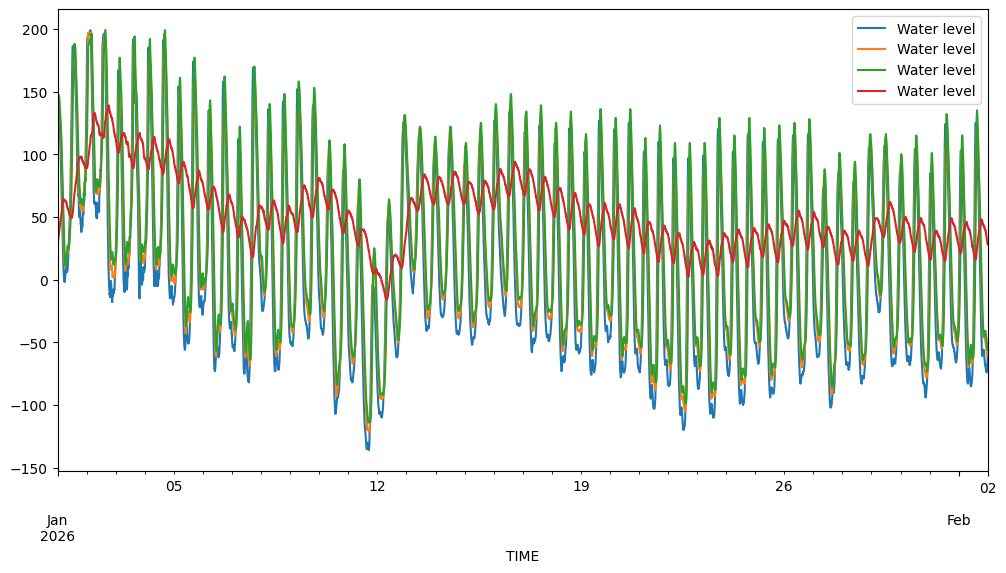

In [94]:
fig,ax = plt.subplots(figsize=[12,6])
HvH_data.plot(ax=ax, label='Hoek van Holland')
botlek_data.plot(ax=ax, label='Botlek')
Rotterdam_data.plot(ax=ax, label='Rotterdam')
Moerdijk_data.plot(ax=ax, label='Moerdijk');